<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido. 

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.


## Desarrollo

## 0. Librerias

In [13]:
# Manejo de datos
import pandas as pd
import numpy as np

# Geo
import geopandas as gpd
import folium
import geojsoncontour
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from sklearn.mixture import GaussianMixture
import branca.colormap as cm

# NLP
import re

# Gráficos
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Utils
from pathlib import Path
import json

# Modelos
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
import statsmodels.api as sm
from statsmodels.nonparametric.kernel_density import KDEMultivariate

# Omitir advertencias
import warnings
warnings.filterwarnings("ignore")


In [3]:
# utils
# rutas absolutas
here: Path = Path.cwd().absolute()
data: Path = here / 'data'

burger_master: Path = data / 'burger_master.xlsx'


### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [4]:
# Utilice este espacio para escribir el código.

# Cargar Chicago_delitos_verano_2019.csv
df = pd.read_excel(burger_master)

# Vista previa de los datos
display(df.head())

# Información de la tabla
print(df.info())

,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Restaurante  137 non-null    object 
 1   Dirección    137 non-null    object 
 2   Descripción  137 non-null    object 
 3   Latitud      137 non-null    float64
 4   Longitud     137 non-null    float64
dtypes: float64(2), object(3)
memory usage: 5.5+ KB
None


In [5]:
df["Restaurante"].value_counts(normalize=True)

Restaurante
LA HAMBURGUESERÍA             0.160584
XL COLOMBIA GOURMET           0.116788
PECADO CAPITAL                0.051095
GRATIN BURGER                 0.043796
LONGO'S (CHORILONGO)          0.029197
                                ...   
PRIMITIVO                     0.007299
EL CHORI CHARRÚA CAMPESTRE    0.007299
DONDE TU QUIERAS              0.007299
ANGUS AZUL BURGER             0.007299
LA HIERRA CHÍA                0.007299
Name: proportion, Length: 63, dtype: float64

In [6]:
len(df["Restaurante"].unique())

63

In [7]:
print(df["Descripción"][0])

<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>


| Campo         | Tipo de dato | Descripción                                                                             |
| ------------- | ------------ | --------------------------------------------------------------------------------------- |
| `Restaurante` | `object`     | Nombre del restaurante incluido en el listado del Burger Master.                        |
| `Dirección`   | `object`     | Dirección física donde se encuentra ubicado el restaurante.                             |
| `Descripción` | `object`     | Breve descripción del restaurante o información adicional relevante sobre su propuesta. Este texto tiene flags de codigo html |
| `Latitud`     | `float64`    | Latitud geográfica del restaurante en formato decimal.                                  |
| `Longitud`    | `float64`    | Longitud geográfica del restaurante en formato decimal.                                 |


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

* Total de filas : 137
* Cantidad de restaurantes únicos: 63
* Coordenadas corresponden correctamente a la ciudad de Bogotá.
* Descripción: Trae información de la descripción d elas hamburguesas y direcciones. Esta data trae marcas html. Se dejarán de esta forma para renderizar en el mapa de mejor manera

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [15]:
# Extraer texto entre <p> y <br> o </p>
regex = re.compile(r'(?<=<p>)(.*?)(?=<br|<\/p>)', re.DOTALL | re.IGNORECASE)

# Funcipon para limpiar la descripción
def extraer_descripcion(texto):
  # Buscamos la coincidencia en el texto
  match = regex.search(str(texto))
  if match:
    # Si la encuentra, devuelve el texto capturado y elimina espacios en blanco
    return match.group(1).strip()
  return "No se encontró descripción"

# Aplicamos la función a la columna 'Descripción' y sobrescribimos la columna
df['Descripción'] = df['Descripción'].apply(extraer_descripcion)

In [16]:
# Utilice este espacio para escribir el código.

# Crear mapa con folium centrado en el promedio de las coordenadas
m = folium.Map(
    location=[df["Latitud"].mean(), df["Longitud"].mean()],
    zoom_start=12
)

# Añadir marcadores con pop-ups
for _, row in df.iterrows():
    popup_html = f"""
    <b>{row['Restaurante']}</b><br>
    {row['Dirección']}<br><br>
    {row['Descripción']}
    """
    folium.Marker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=row['Restaurante']
    ).add_to(m)

# Guardar o mostrar el mapa
m.save("mapa_burger_master.html")
m

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Con ayuda de Fomulium mostramos el mapa cnetrandolo usando el promedio de las latitudes y longitudes. Luego se itera en las filas y se usa folium.Popup(popup_html, max_width=300) para en cada marcador poder rendereizar las descripciones de las hamburguesas limpias. 

Para limpiar los textos se usó una regex que captura todo lo que está juesto después de un \<p> y antes de un \<br> o \</p>

Nota: de no poder ver el mapa en notebook, se añade la linea m.save("mapa_burger_master.html") para que la persona que revise pueda abrir el html en el navegador de su preferencias.


### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

In [18]:
# Utilice este espacio para escribir el código.

#Guardamos as parejas de coordenadas en una matriz
coords = df[["Longitud", "Latitud"]].values

# Inicializamos listas vacias para guardar BIC y AIC para determinar cuántas componentes usar
bic = []
aic = []

# Iniciamos un rango de componentes a evaluar
n_components = range(1, 11)

# iteramos sobre los componentes, ajustamos el modelo y guardamos los criterios. Establecemos semilla para reproducibilidad
for k in n_components:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=123)
    gmm.fit(coords)
    bic.append(gmm.bic(coords))
    aic.append(gmm.aic(coords))

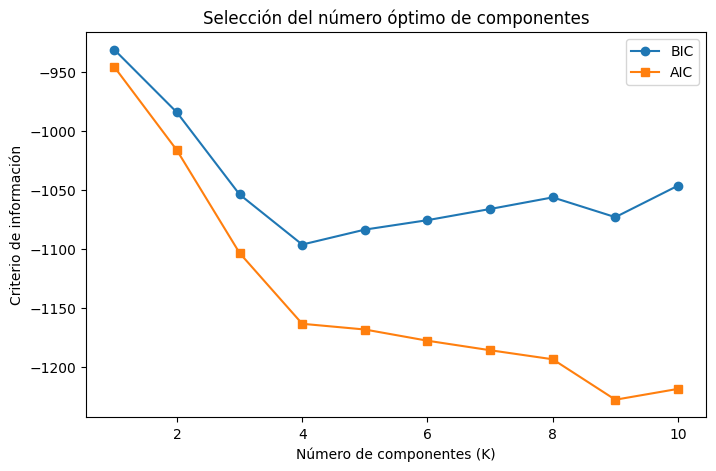

In [19]:
# Visualizar criterios
plt.figure(figsize=(8,5))
plt.plot(n_components, bic, label="BIC", marker='o')
plt.plot(n_components, aic, label="AIC", marker='s')
plt.xlabel("Número de componentes (K)")
plt.ylabel("Criterio de información")
plt.title("Selección del número óptimo de componentes")
plt.legend()
plt.show()

In [20]:
# Seleccionamos el numéro de componentes optimo basados en el cirtierio BIC
# Más adelante explicaremos por qué usamos BIC en lugar de AIC
optimal_k = np.argmin(bic) + 1  # selecciona el K con menor BIC

# Creamos el modelo GMM y dejamos semilla fija para reproducibilidad
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=123)
gmm.fit(coords)
labels = gmm.predict(coords)

# Finalmente, añadimos las etiquetas al DataFrame original
df["Cluster"] = labels

In [21]:
# Imprimimos las primeras filas para verificar
df["Cluster"].head()

0    0
1    2
2    2
3    2
4    2
Name: Cluster, dtype: int64

Para identificar posibles puntos calientes asociados a la distribución de los restaurantes del Burguer MAster en Bogotá se aplica un modelo de Mezclas Gaussianas (Gaussian Mixture Model). Tomamos las latitudes y longitudes para estimar las funciones de probabilidad de mezclas gaussianas y así poder identificar posibles puntos calientes en el mapa.

Como tenemos puntos a lo largo de todo Bogotá, usamos la estructura de covarianzas 'full' ya que permite que cada matriz tenga su propia matriz de covarianza completa. Esta elección no limita a que las densidades sigan algún patrón circulas o elíptico. Entonces, al permitir que cada componente pueda tener su propia matriz de covariazna, el modelo se adapta mejor a los datos para describir formas y orientaciones. 

Un 'contra' de esta elección es que es la más demandante a nivel de recursos computacionales, sin embargo, como vimos en la descripción de los datos, contamos con apenas 137 filas en el Data Frame. Es decir, contamos con 137 puntos rendrizados en el mapa de Bogotá. Al ser tan pocos registros vale mucho la pena decatarnos por la estructura full apra lograr una mejor adapatación a los datos.

Por otra parte, para determinar el número de componentes se usan los dos criterios BIC y AIC para ilustrar al lector. Sin embargo, siguiendo la sugerncias vistas en clase y además considerando que BIC penaliza más fuerte la complejidad del modelo, tomamos este criterio como principal para el modelo y así poder evitar un posible sibreajuste al introducir más componentes que las necesarias.

Notemos además, que para este caso ambas coinciden con un mínimo en 4. A pesar de que AIC sigue decreciendo, cada componente que se añade no agrega mejoras significativas. Por esta razón adicional y las antes expuestas se decide tomar 4 como componentes del modelo. Esto se traduce además, que podemos agrupar los puntos en 4 cluster. Es necesario además aclarar que, aunque GMM puede servir para clusterizar, su objetivo principal es el de ecnotrar densidades.

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [22]:
# Definición de funciones para renderizar densiades en mapa

# --- 1. Función para calcular densidad GMM en grilla ---
def calcular_gmm_grid(modelo, datos, n_grid=150):
    """
    Calcula la densidad estimada por un modelo GMM en una grilla de puntos.

    Args:
        modelo (GaussianMixture): Modelo GMM entrenado.
        datos (np.ndarray): Array con coordenadas (lon, lat).
        n_grid (int): Resolución de la grilla.

    Returns:
        tuple: (pdf_grid, grid_lon, grid_lat)
    """
    lon_min, lat_min = datos.min(axis=0) - 0.01
    lon_max, lat_max = datos.max(axis=0) + 0.01
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:n_grid*1j, lat_min:lat_max:n_grid*1j]

    puntos = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    pdf = np.exp(modelo.score_samples(puntos))
    pdf_grid = pdf.reshape(grid_lon.shape)

    return pdf_grid, grid_lon, grid_lat


# --- 2. Crear GeoJSON de curvas de nivel ---
def crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa='Reds'):
    fig, ax = plt.subplots(figsize=(8, 8))
    contour_plot = ax.contourf(
        grid_lon, grid_lat, pdf_grid,
        levels=15, cmap=color_mapa, alpha=0.9
    )
    plt.close(fig)
    try:
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5
        )
    except Exception as e:
        print(f"Error en conversión directa: {e}")
        cmap = plt.get_cmap(color_mapa)
        base_color = to_rgba(cmap(0.5))
        hex_color = '#%02x%02x%02x' % tuple([int(255 * x) for x in base_color[:3]])
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5,
            geojson_properties={
                'stroke': hex_color,
                'fill': hex_color,
                'stroke-width': 1,
                'fill-opacity': 0.5
            }
        )


# --- 3. Añadir capa GeoJSON al mapa ---
def agregar_capas_a_mapa(mapa, geojson_data, nombre_capa, opacidad_fondo=0.3):
    if geojson_data:
        folium.GeoJson(
            json.loads(geojson_data),
            name=nombre_capa,
            style_function=lambda feature: {
                'fillColor': feature['properties'].get('fill', '#000000'),
                'fillOpacity': opacidad_fondo,
                'color': feature['properties'].get('stroke', '#000000'),
                'weight': feature['properties'].get('stroke-width', 2),
            }
        ).add_to(mapa)
        
    else:
        print(f"❌ No se pudo añadir la capa '{nombre_capa}'.")

Para facilidad de la implemntación del mapa se definie un conjunto de funciones que ayudarán en la construcción de lo necesario para la renderización:
* **calcular_gmm_grid**: Calcula la densidad estimada por un modelo GMM en una grilla de puntos. Esta grilla es creada teniendo en cuenta los puntos mínimos y máximos del conjunto de datos.
* c**rear_geojson_contorno()**: Esta función nos ayuda a tomar el resultado de calcular_gmm_grid graficado con matplolib y convertiro en un formato GeoJson para incorporar elmentos (en este caso poligonos) dentro del mapa mucho más facilmente.
* **agregar_capas_a_mapa**: por último, se toman los GeoJson y las dibuja directamente en el mapa apoyado de folium


In [23]:
# --- 4. Calcular densidades en la grilla ---
pdf_grid, grid_lon, grid_lat = calcular_gmm_grid(gmm, coords)

# --- 5. Crear GeoJSON de curvas ---
geojson_data = crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa="Reds")

# --- 6. Crear mapa base ---
m = folium.Map(
    location=[df["Latitud"].mean(), df["Longitud"].mean()],
    zoom_start=10.5
)

# --- 7. Añadir capa de densidad ---
agregar_capas_a_mapa(m, geojson_data, "Curvas de densidad GMM", opacidad_fondo=0.5)

# --- 8. Añadir puntos individuales ---
colormap = cm.linear.viridis.scale(0, gmm.n_components)
for _, row in df.iterrows():
    popup_html = f"""
    <b>{row['Restaurante']}</b><br>
    {row['Dirección']}<br><br>
    {row['Descripción']}
    """
    folium.CircleMarker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(popup_html, max_width=300),
        color=colormap(row["Cluster"]),
        radius=5,
        tooltip=row['Restaurante'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)


# --- 10. Control de capas ---
folium.LayerControl().add_to(m)

# --- 11. Guardar mapa ---
m.save("mapa_curvas_densidad_gmm.html")
m


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Tenemos como resultado un mapa con los puntos de los restaurantes participantes del burguer master en Bogotá junto con las densidades de 4 clusters resultantes de las 4 componentes del modelo de mexclas gaussians. 

El cluster verde es el que tiene mayir concentración de puntos, acá las curvas de nivel tienen un rojo mas intenso para determianr que es una zona densa. Es de reslatar que esta zona corresponde a barrios como Chapinero, Zona G, Parque de la 93 y Usaquén que son reconocidos por su alta oferta gastonómica

Otro foco intersante es el occidente de Bogotá donde se pueden concentrar más sectores residenciales junto con comerciales, pero denota un crecimiento en sector gastronómico descentralizado pero marcado en el occidente.

Cabe mencionar que existe una pequeña densidad en el norte de Bogotá, correspondiente a Chía que cuenta con algunos restaurantes participantes en el Burguer Master

Conclusiones: Las zonas centro norte son las que concentran la mayor oferta gastronómica de restaurantes del Burguer Master. Las zonas períféricas mustran baja densidad (dispersión) de restaurantes, esto puede ser una indicador intersante puesto que exhibie que la oferta gastonómica de Bogotá puede esatr creciendo y no sólo está concentrada en el centro norte. Sin embargo, y es importante anotar, las densidades anteriores intenat acoplarse a los datos pero su acople no es muy fino, las densidades parecen abarcar zonas más grandes de lo que realmente son e incluso abarcar zonas que no tienen puntos. 

Si ud quiere probar alguna hamburguesa de esta competencia, se le recomienda que no piense solamente en el centro norte, sino que pueda también darle la oportunidad a la zona sur y occidental. Si se siente motivado a viajar hasta Chía, no pierda la oprtunidad de poder probar a los competidores de la zona norte.



(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG. 

In [24]:
# Cración modelo KDE con statsmodels para comparar usando bw='cv_ml'
kde = KDEMultivariate(data=coords.T,var_type='cc',bw='cv_ml')

print("Parámetros óptimos del KDE:")
print("Anchos de banda:", kde.bw)

Parámetros óptimos del KDE:
Anchos de banda: [0.00404396 0.00609795]


In [25]:
# --- 1. Función para calcular densidad KDE en grilla ---
def calcular_kde_grid(modelo, datos, n_grid=150):
    """
    Calcula la densidad estimada por un modelo KDE en una grilla de puntos.

    Args:
        modelo (KDEMultivariate): Modelo KDE entrenado.
        datos (np.ndarray): Array con coordenadas (lon, lat).
        n_grid (int): Resolución de la grilla.

    Returns:
        tuple: (pdf_grid, grid_lon, grid_lat)
    """
    lon_min, lat_min = datos.min(axis=0) - 0.01
    lon_max, lat_max = datos.max(axis=0) + 0.01
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:n_grid*1j, lat_min:lat_max:n_grid*1j]

    puntos = np.vstack([grid_lon.ravel(), grid_lat.ravel()])
    pdf = modelo.pdf(puntos)
    pdf_grid = pdf.reshape(grid_lon.shape)

    return pdf_grid, grid_lon, grid_lat


In [26]:
# --- 2. Calcular densidades en la grilla ---
pdf_grid, grid_lon, grid_lat = calcular_kde_grid(kde, coords)

# --- 3. Crear GeoJSON de curvas ---
geojson_data = crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa="Reds")

# --- 4. Crear mapa base ---
m = folium.Map(
    location=[df["Latitud"].mean(), df["Longitud"].mean()],
    zoom_start=10.5
)

# --- 5. Añadir capa de densidad KDE ---
agregar_capas_a_mapa(m, geojson_data, "Curvas de densidad KDE", opacidad_fondo=0.5)

# --- 6. Añadir puntos individuales ---
colormap = cm.linear.viridis.scale(0, gmm.n_components)
for _, row in df.iterrows():
    popup_html = f"""
    <b>{row['Restaurante']}</b><br>
    {row['Dirección']}<br><br>
    {row['Descripción']}
    """
    folium.CircleMarker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(popup_html, max_width=300),
        color=colormap(row["Cluster"]),
        radius=5,
        tooltip=row['Restaurante'],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

# --- 7. Añadir control de capas ---
folium.LayerControl().add_to(m)

# --- 8. Guardar mapa ---
m.save("mapa_curvas_densidad_kde.html")
m


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Indiscutibelmente las densidades generadas por KDE se adaptan mucho mejor a los puntos vs GMM. Notese que en el mapa anterior se pueden identificar grupo de puntos desde el sur hasta el norte. Ahora el clsuter verde tiene densidades marcadas en el sur, centro y centro-norte. Esto no sucedía en GMM puesto que las curvas abarcaban todos los puntos en un cluster grande.

Lo mismo sucede en la zona occidental, se puede ver un cluster denso en la carrera 75 con calle 24, comparado con GMM, este resultado es mucho más fino y se adapta mucho mejor a los datos. GMM generaba un gran cluster en la zona occidental con curvas poca intensas.

La zona centro-norte marca una densidad en la calle 147 con carrera 15 y en la zona norte, hace la distinción de de dos densidades en chía.

Conclusión: KDE puede ser más costoso computacionalmente, sin embargo, genera densidades que se adaptan mucho mejor a los datos. Por otro lado, GMM al ser no parámetrica puede ejecutarse de forma más rápida y arroja muy buenos resultados. Dependerá del tipo de analisis y resultados a mostrar del analista cual de los 2 usar. GMM puede servir para dar un primer vistazo de las densidades y posteriormente puntualizar con KDE.


